<a href="https://colab.research.google.com/github/PRIOTOM/Gold-Price-History-1833-2026-/blob/main/Gold_price_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Dataload Using Kagglehub
path = kagglehub.dataset_download("uzmaakhtar/gold-price-history-18332026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gold-price-history-18332026' dataset.
Path to dataset files: /kaggle/input/gold-price-history-18332026


In [5]:
# Show first 5 rows of data
df = pd.read_csv('/kaggle/input/gold-price-history-18332026/gold_advanced_features.csv')
df.head()

,date,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,...,roll_std_6,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3
0,1834-01-01,18.93,1834,1,1,0.500000,8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1,1834-02-01,18.93,1834,2,1,0.866025,5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
2,1834-03-01,18.93,1834,3,1,1.000000,6.123234e-17,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
3,1834-04-01,18.93,1834,4,2,0.866025,-5.000000e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
4,1834-05-01,18.93,1834,5,2,0.500000,-8.660254e-01,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0


In [6]:
# Number of rows and columns in dataframe
df.shape

(2306, 26)

In [7]:
# Datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             2306 non-null   object 
 1   price            2306 non-null   float64
 2   year             2306 non-null   int64  
 3   month            2306 non-null   int64  
 4   quarter          2306 non-null   int64  
 5   month_sin        2306 non-null   float64
 6   month_cos        2306 non-null   float64
 7   lag_1            2306 non-null   float64
 8   lag_2            2306 non-null   float64
 9   lag_3            2306 non-null   float64
 10  lag_6            2306 non-null   float64
 11  lag_12           2306 non-null   float64
 12  roll_mean_3      2306 non-null   float64
 13  roll_mean_6      2306 non-null   float64
 14  roll_mean_12     2306 non-null   float64
 15  roll_std_3       2306 non-null   float64
 16  roll_std_6       2306 non-null   float64
 17  momentum_1    

In [8]:
# Separate date and month from a column
df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

df.drop(columns=['date'], inplace=True)
df.head()

,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,...,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3,day
0,18.93,1834,1,1,0.500000,8.660254e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1
1,18.93,1834,2,1,0.866025,5.000000e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1
2,18.93,1834,3,1,1.000000,6.123234e-17,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1
3,18.93,1834,4,2,0.866025,-5.000000e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1
4,18.93,1834,5,2,0.500000,-8.660254e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0,1


In [9]:
# Descriptive statistics of data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,2306.0,233.342338,509.783501,17.060000,18.940000,2.069000e+01,179.240000,5019.970000
year,2306.0,1929.583695,55.485647,1834.000000,1882.000000,1.930000e+03,1978.000000,2026.000000
month,2306.0,6.495663,3.454473,1.000000,3.000000,6.000000e+00,9.000000,12.000000
quarter,2306.0,2.498699,1.118664,1.000000,1.000000,2.000000e+00,3.000000,4.000000
month_sin,2306.0,0.000592,0.707260,-1.000000,-0.500000,1.224647e-16,0.774519,1.000000
month_cos,2306.0,0.000592,0.707260,-1.000000,-0.500000,6.123234e-17,0.774519,1.000000
lag_1,2306.0,231.173631,499.954410,17.060000,18.940000,2.068500e+01,178.155000,4752.750000
lag_2,2306.0,229.120803,491.019390,17.060000,18.940000,2.068000e+01,177.682500,4309.230000
lag_3,2306.0,227.260309,483.625365,17.060000,18.940000,2.068000e+01,176.300000,4087.190000
lag_6,2306.0,222.162126,464.712320,17.060000,18.940000,2.068000e+01,172.945000,3368.030000


In [10]:
# Unique values number in every columns
df.nunique()

,0
price,734
year,193
month,12
quarter,4
month_sin,11
month_cos,11
lag_1,733
lag_2,732
lag_3,731
lag_6,728


In [11]:
# Check empty values
df.isnull().sum()

,0
price,0
year,0
month,0
quarter,0
month_sin,0
month_cos,0
lag_1,0
lag_2,0
lag_3,0
lag_6,0


In [12]:
# Split dataset for training

from sklearn.model_selection import train_test_split
tar_col = 'price'

X = df.drop(columns=[tar_col])
y = df[tar_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

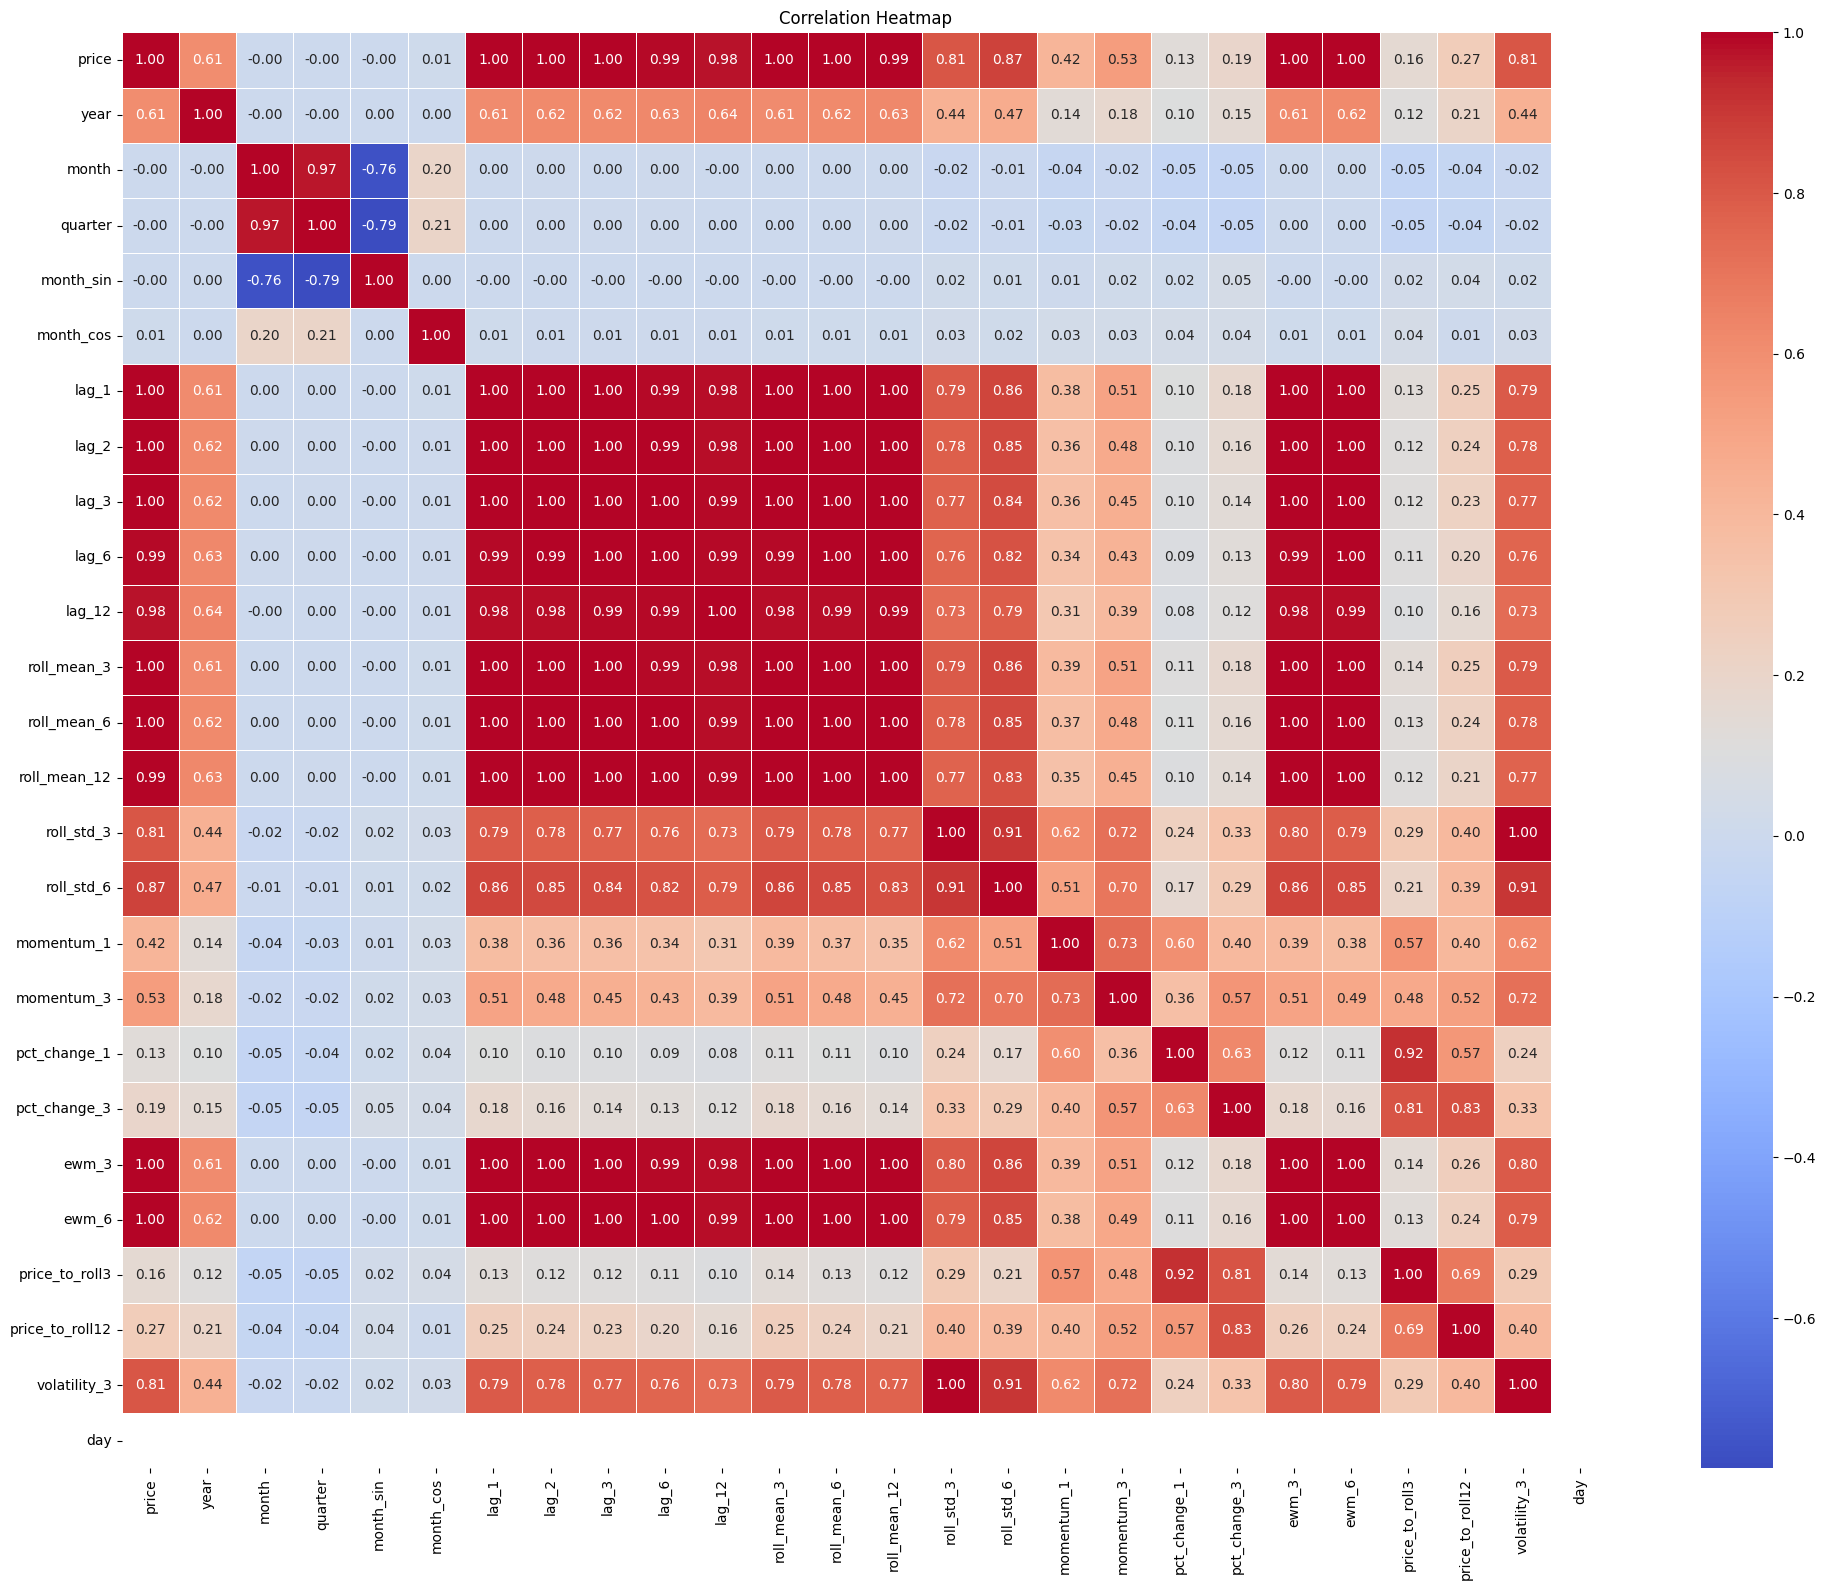

In [13]:
# Correlation heatmap of data
corr_mat = df.corr()
plt.figure(figsize=(20,16))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm",fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
# Train Linearregression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

In [15]:
# Function for train and test result
def regression_metrics(y_true, y_pred, label='Model'):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'=== {label} ====')
  print('MAE: ', mae)
  print('MSE: ', mse)
  print('RMSE: ', rmse)
  print('R2 : ', r2)
  print()

# Evaluate on train and test
regression_metrics(y_train, y_train_pred, label='Linear Regression (Train)')
regression_metrics(y_test, y_test_pred, label='Linear Regression (Test)')

=== Linear Regression (Train) ====
MAE:  5.904556188405583e-14
MSE:  1.0284288928030156e-26
RMSE:  1.0141148321580823e-13
R2 :  1.0

=== Linear Regression (Test) ====
MAE:  6.45178955955329e-14
MSE:  1.4065738268282556e-26
RMSE:  1.1859906520829983e-13
R2 :  1.0



#Explain Linear Regression result

The Linear Regression model shows perfect performance with R² = 1.0 and near-zero MAE, MSE, and RMSE on both training and test data. While this suggests an ideal fit, such results are unrealistic for the dataset gold prices and strongly indicate data leakage. This means the model likely had access to information that directly or indirectly contains the target value. Therefore, the model is not truly predicting but memorizing the data.

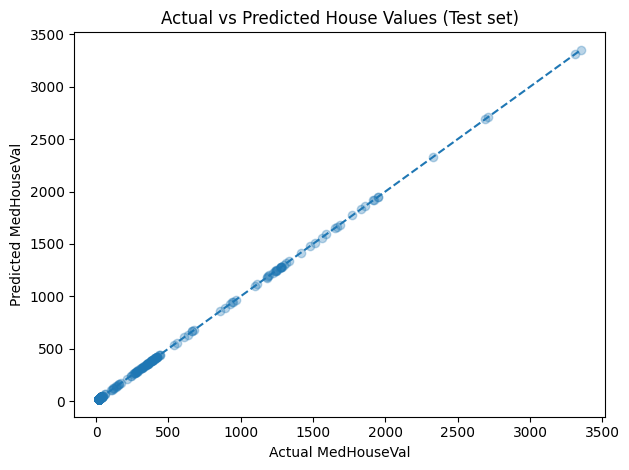

In [16]:
# Plot predicted vs actual values on the test set

plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Actual vs Predicted House Values (Test set)')

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.tight_layout()
plt.show()

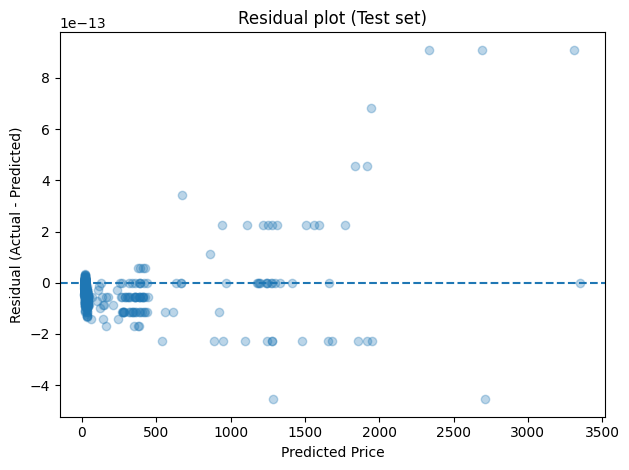

In [17]:
# Residual plot (errors = actual - predicted)

residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual plot (Test set)')
plt.tight_layout()
plt.show()

In [18]:
# Scale Dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# Train SVR model
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale')
svr.fit(X_train_scaled, y_train)

y_train_pred_svr = svr.predict(X_train_scaled)
y_test_pred_svr = svr.predict(X_test_scaled)
regression_metrics(y_train, y_train_pred_svr, label='SVR (Train)')
regression_metrics(y_test, y_test_pred_svr, label='SVR (Test)')


=== SVR (Train) ====
MAE:  82.32449609024142
MSE:  108724.74549367807
RMSE:  329.7343559498738
R2 :  0.5897666985850822

=== SVR (Test) ====
MAE:  76.79729800512504
MSE:  83088.78410334456
RMSE:  288.2512516943241
R2 :  0.6519862941554404



#Explain SVR model result

The Support Vector Regression (SVR) model demonstrates moderate and realistic predictive performance, achieving an R² score of 0.59 on the training set and 0.65 on the test set. This indicates that the model is able to capture approximately 60–65% of the variance in gold price movements, which is a reasonable outcome given the inherent volatility and noise present in financial time-series data. The relatively close alignment between training and testing performance suggests that the model generalizes well and does not exhibit significant overfitting.

In [20]:
#Train RandomforestRegressor

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_train_pred_rf = rf.predict(X_train_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

regression_metrics(y_train, y_train_pred_rf, label='RandomForestRegressor (Train)')
regression_metrics(y_test, y_test_pred_rf, label='RandomForestRegressor (Test)')

=== RandomForestRegressor (Train) ====
MAE:  1.7188555314534155
MSE:  65.79291076698617
RMSE:  8.11128292978282
R2 :  0.999751754369522

=== RandomForestRegressor (Test) ====
MAE:  4.012378463203467
MSE:  182.08043419377265
RMSE:  13.49371832349307
R2 :  0.9992373641358532



# Explain Randomforestregressor model result

The Random Forest Regressor exhibits extremely high predictive performance, achieving R² scores of 0.9997 on the training set and 0.9992 on the test set, along with very low MAE and RMSE values. While the close alignment between training and testing results suggests minimal overfitting, such near-perfect accuracy is uncommon for financial time-series data like gold prices. This raises the possibility of data leakage or the presence of highly correlated features that may indirectly encode the target variable.